# Step 1: Importing Libraries and Loading the Dataset

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report,accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score, train_test_split
import warnings
warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv("ILPD.csv")

# Step 2: Exploratory Data Analysis (EDA)

In [12]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [13]:
# Analyze the distributions and summary statistics of the columns
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [14]:
# Check the data types of the columns
df.dtypes

Age            int64
Gender        object
TB           float64
DB           float64
Alkphos        int64
Sgpt           int64
Sgot           int64
TP           float64
ALB          float64
A/G Ratio    float64
Selector       int64
dtype: object

In [15]:
# Identify missing values
df.isnull().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    4
Selector     0
dtype: int64

# Step 3: Data Preprocessing

In [16]:
# Separate the features (X) and the target variable (y)
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [17]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Step 5: Model training and Evaluation

In [18]:
# Initialize the Logistic Regression model
model = LogisticRegression()

In [19]:
df.columns

Index(['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB',
       'A/G Ratio', 'Selector'],
      dtype='object')

In [20]:
# Define the columns that need imputation and encoding
numeric_features = ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']
categorical_features = ['Gender']

# Create transformers for numerical and categorical features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)
categorical_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder()
)

# Combine the transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'  # Drop any remaining columns not specified
)


In [21]:
y_train.value_counts()

Selector
1    329
2    137
Name: count, dtype: int64

In [22]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot',
                                  'TP', 'ALB', 'A/G Ratio']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder())]),
                                 ['Gender'])])

In [23]:
x_trainp=preprocessor.fit_transform(x_train)
x_testp=preprocessor.transform(x_test)

In [24]:
lr= LogisticRegression()

model=lr.fit(x_trainp,y_train)

In [25]:
# Predict on test data
y_pred = model.predict(x_testp)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.7606837606837606


Confusion Matrix:
[[80  7]
 [21  9]]


<Axes: >

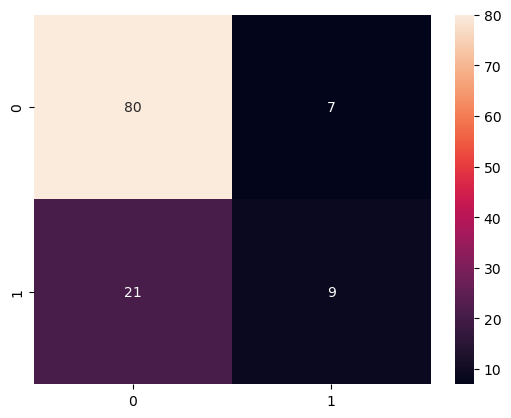

In [26]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

sns.heatmap(cm,annot=True)

In [27]:
# Generate classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.92      0.85        87
           2       0.56      0.30      0.39        30

    accuracy                           0.76       117
   macro avg       0.68      0.61      0.62       117
weighted avg       0.73      0.76      0.73       117



In [28]:
roc_auc_score(y_test, y_pred)

np.float64(0.6097701149425288)

# Step 6: Feature Importance

In [29]:
p = {
    'C': [0.1, 1.0, 10.0,20.0,30.0],
    'penalty': ['l1', 'l2','elasticnet'],
    'l1_ratio':[0.1,0.2,0.3,0.4,0.5],
    'max_iter':[100,200,300,400,500,600]
}

In [30]:
lr=LogisticRegression(solver="saga")

In [31]:

logreg_grid_search = GridSearchCV(lr, p, cv=5, return_train_score=True)


In [32]:
logreg_grid_search.fit(x_trainp,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(solver='saga'),
             param_grid={'C': [0.1, 1.0, 10.0, 20.0, 30.0],
                         'l1_ratio': [0.1, 0.2, 0.3, 0.4, 0.5],
                         'max_iter': [100, 200, 300, 400, 500, 600],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             return_train_score=True)

l1_ratio is a parameter in a [0,1] range weighting l1 vs l2 regularisation. Hence the amount of l1 regularisation is l1_ratio * 1./C, likewise the amount of l2 reg is (1-l1_ratio) * 1./C

In [33]:
logreg_grid_search.cv_results_

{'mean_fit_time': array([0.0115932 , 0.00946631, 0.01117196, 0.01120987, 0.01208076,
        0.0173285 , 0.01160989, 0.01541328, 0.0174881 , 0.01278739,
        0.01378155, 0.01414924, 0.01131878, 0.01184435, 0.01531477,
        0.01056767, 0.01346359, 0.01699061, 0.00917192, 0.00873446,
        0.01217403, 0.01313958, 0.01122785, 0.01725092, 0.00981369,
        0.01343584, 0.01682076, 0.0118012 , 0.01411767, 0.01735868,
        0.01073017, 0.01244893, 0.01694417, 0.01331859, 0.0135004 ,
        0.01701531, 0.00969377, 0.00938268, 0.00904875, 0.01200671,
        0.0135015 , 0.0176609 , 0.01131792, 0.01515522, 0.0163074 ,
        0.01516294, 0.01640315, 0.01870556, 0.00986643, 0.01479969,
        0.01752501, 0.01230655, 0.01505365, 0.01342902, 0.01097312,
        0.0108222 , 0.01250072, 0.01310873, 0.01573615, 0.01687522,
        0.01059737, 0.01456981, 0.01662197, 0.01250505, 0.01319222,
        0.01654477, 0.01166906, 0.01553488, 0.01588635, 0.01325026,
        0.01414781, 0.01678982,

In [34]:
logreg_grid_search.best_estimator_

LogisticRegression(C=10.0, l1_ratio=0.5, penalty='l1', solver='saga')

In [36]:
finallr=LogisticRegression(C=10.0, l1_ratio=0.2, penalty='l1', solver='saga')
model1=finallr.fit(x_trainp,y_train)

In [37]:
# Predict on test data
y_pred = model1.predict(x_testp)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7606837606837606


Confusion Matrix:
[[80  7]
 [21  9]]


<Axes: >

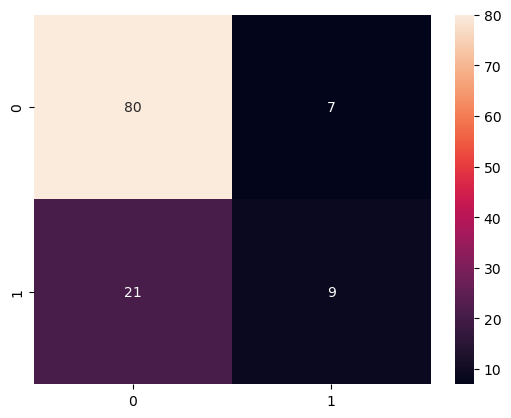

In [38]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

sns.heatmap(cm,annot=True)

In [39]:
# Generate classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.92      0.85        87
           2       0.56      0.30      0.39        30

    accuracy                           0.76       117
   macro avg       0.68      0.61      0.62       117
weighted avg       0.73      0.76      0.73       117



In [40]:
import seaborn as sns



In [41]:
data=sns.load_dataset("iris")

In [42]:
fv=data.iloc[:,0:-1]
cv=data.iloc[:,-1]

In [43]:
cv.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [44]:
cv=cv.map({"setosa":0,"versicolor":1,"virginica":2})

In [45]:
lr11=LogisticRegression()
lr11.fit(fv.iloc[:,2:],cv)

LogisticRegression()

In [46]:
from mlxtend.plotting import plot_decision_regions

ModuleNotFoundError: No module named 'mlxtend'

In [ ]:
lr11=LogisticRegression()
lr11.fit(fv.iloc[:,2:],cv)
plot_decision_regions(X=fv.iloc[:,2:].values,y=cv.values,clf=lr11)

In [ ]:
p = {
    'C': [0.1, 1.0, 10.0,20.0,30.0],
    'penalty': ['l1', 'l2','elasticnet'],
    'l1_ratio':[0.1,0.2,0.3,0.4,0.5],
    'max_iter':[100,200,300,400,500,600]
}

In [ ]:
lr111=LogisticRegression(solver="saga")
lrm = GridSearchCV(lr111, p, cv=5, return_train_score=True)
lrm.fit(fv.iloc[:,2:],cv)

In [ ]:
lrm.best_params_

In [ ]:
lrm.best_estimator_

In [ ]:
fl=LogisticRegression(C=0.1, l1_ratio=0.1, solver='saga')
fl.fit(fv.iloc[:,2:],cv)

In [ ]:
plot_decision_regions(X=fv.iloc[:,2:].values,y=cv.values,clf=fl)
fv.iloc[:,2:],cv

In [ ]:
lr11=LogisticRegression()
lr11.fit(fv.iloc[:,2:],cv)
plot_decision_regions(X=fv.iloc[:,2:].values,y=cv.values,clf=lr11)